In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.random.set_seed(42)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2937s 17us/step
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)


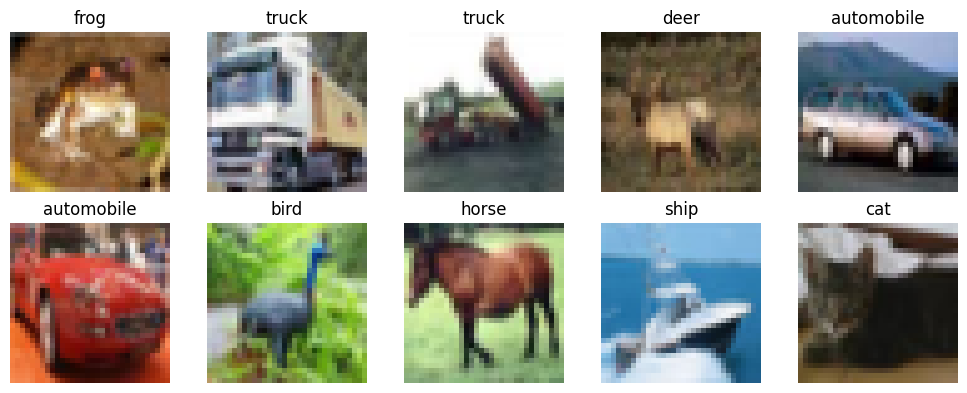

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0



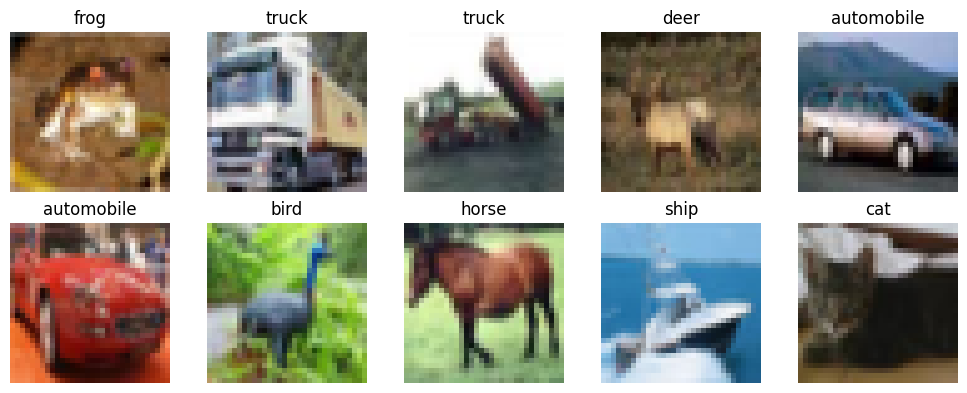

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()
plt.savefig("Sample_Images.eps",dpi=600)


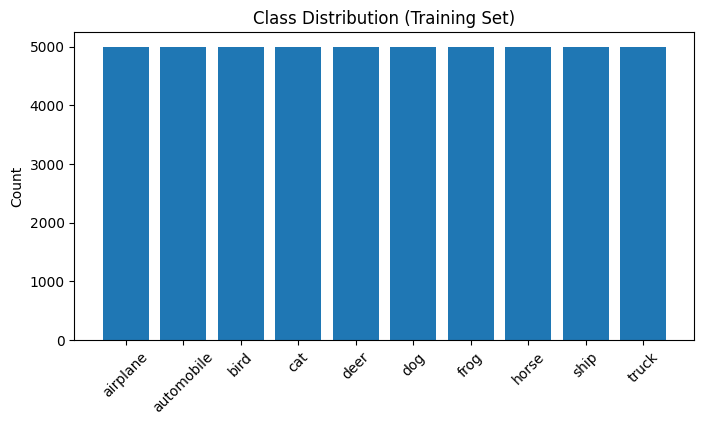

<Figure size 640x480 with 0 Axes>

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8,4))
plt.bar([class_names[u] for u in unique], counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (Training Set)")
plt.ylabel("Count")
plt.show()
plt.savefig("class_distribution.eps",dpi=600)


In [ ]:

sample_image = x_train[0:1]

configs = [
    {"kernel": 3, "stride": 1, "padding": "same"},
    {"kernel": 5, "stride": 1, "padding": "same"},
    {"kernel": 7, "stride": 1, "padding": "same"},
    {"kernel": 3, "stride": 2, "padding": "valid"},
]

for cfg in configs:
    layer = layers.Conv2D(filters=8, kernel_size=cfg["kernel"],
                           strides=cfg["stride"], padding=cfg["padding"])
    out = layer(sample_image)
    print(f"Kernel={cfg['kernel']}, Stride={cfg['stride']}, "
          f"Padding={cfg['padding']} -> Output shape: {out.shape}")

Kernel=3, Stride=1, Padding=same -> Output shape: (1, 32, 32, 8)
Kernel=5, Stride=1, Padding=same -> Output shape: (1, 32, 32, 8)
Kernel=7, Stride=1, Padding=same -> Output shape: (1, 32, 32, 8)
Kernel=3, Stride=2, Padding=valid -> Output shape: (1, 15, 15, 8)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                     validation_data=(x_test, y_test),
                     epochs=20,
                     batch_size=32)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4768 - loss: 1.4589 - val_accuracy: 0.5845 - val_loss: 1.1853
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6032 - loss: 1.1198 - val_accuracy: 0.6185 - val_loss: 1.0803
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6557 - loss: 0.9796 - val_accuracy: 0.6459 - val_loss: 1.0154
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6924 - loss: 0.8809 - val_accuracy: 0.6559 - val_loss: 1.0014
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7210 - loss: 0.7982 - val_accuracy: 0.6571 - val_loss: 1.0229
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7488 - loss: 0.7251 - val_accuracy: 0.6495 - val_loss: 1.0817
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7707 - loss: 0.6621 - val_accuracy: 0.6486 - val_loss: 1.1483
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7918 - loss: 0.6046 -

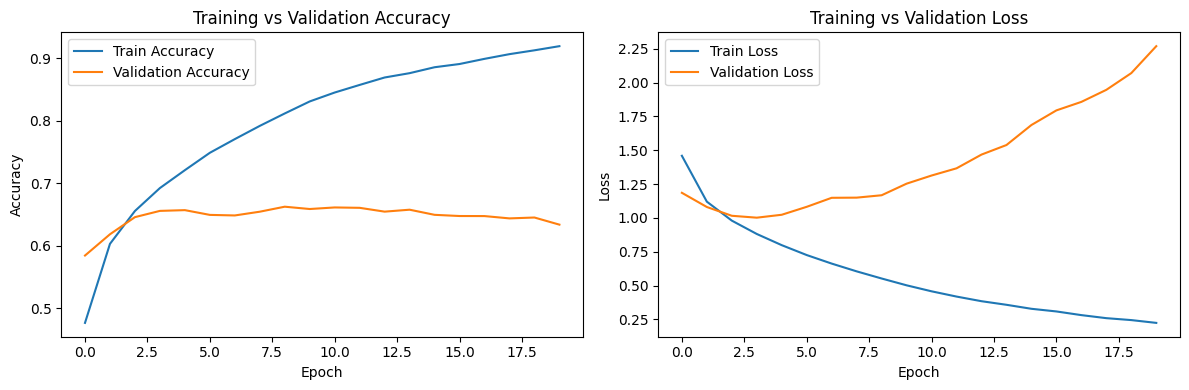

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Training vs Validation Loss')

plt.tight_layout()
plt.show()
plt.savefig("accuracyandloss.eps",dpi=600)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


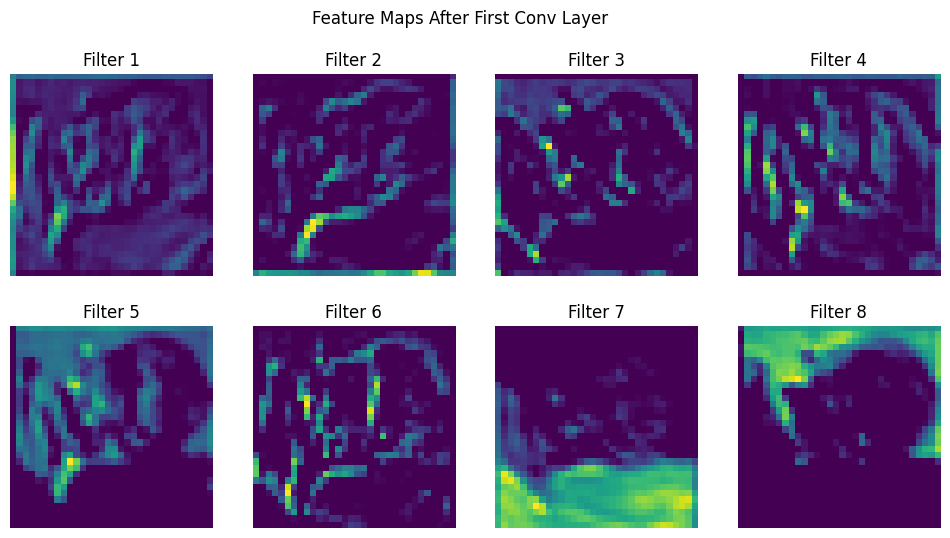

<Figure size 640x480 with 0 Axes>

In [ ]:
# Build a model that outputs the first conv layer's activations
layer_outputs = [model.layers[0].output]
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

test_img = x_test[0:1]
activations = activation_model.predict(test_img)

plt.figure(figsize=(12,6))
for i in range(8):  # display 8 feature maps
    plt.subplot(2,4,i+1)
    plt.imshow(activations[0,:,:,i], cmap='viridis')
    plt.axis('off')
    plt.title(f"Filter {i+1}")
plt.suptitle("Feature Maps After First Conv Layer")
plt.show()
plt.savefig("Filters.eps",dpi=600)


In [ ]:
model_avg = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    layers.AveragePooling2D((2,2)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.AveragePooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_avg.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_avg = model_avg.fit(x_train, y_train,
                             validation_data=(x_test, y_test),
                             epochs=20, batch_size=32)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4469 - loss: 1.5373 - val_accuracy: 0.5341 - val_loss: 1.3001
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5643 - loss: 1.2268 - val_accuracy: 0.5832 - val_loss: 1.1720
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6100 - loss: 1.1017 - val_accuracy: 0.6100 - val_loss: 1.1021
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6430 - loss: 1.0120 - val_accuracy: 0.6199 - val_loss: 1.0715
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6710 - loss: 0.9393 - val_accuracy: 0.6358 - val_loss: 1.0440
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6932 - loss: 0.8769 - val_accuracy: 0.6431 - val_loss: 1.0258
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7133 - loss: 0.8213 - val_accuracy: 0.6450 - val_loss: 1.0322
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7317 - loss: 0.7725 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    airplane       0.78      0.62      0.69      1000
  automobile       0.83      0.65      0.73      1000
        bird       0.59      0.43      0.50      1000
         cat       0.40      0.52      0.46      1000
        deer       0.50      0.70      0.58      1000
         dog       0.63      0.47      0.54      1000
        frog       0.66      0.71      0.68      1000
       horse       0.68      0.74      0.71      1000
        ship       0.78      0.74      0.76      1000
       truck       0.67      0.76      0.71      1000

    accuracy                           0.63     10000
   macro avg       0.65      0.63      0.64     10000
weighted avg       0.65      0.63      0.64     10000



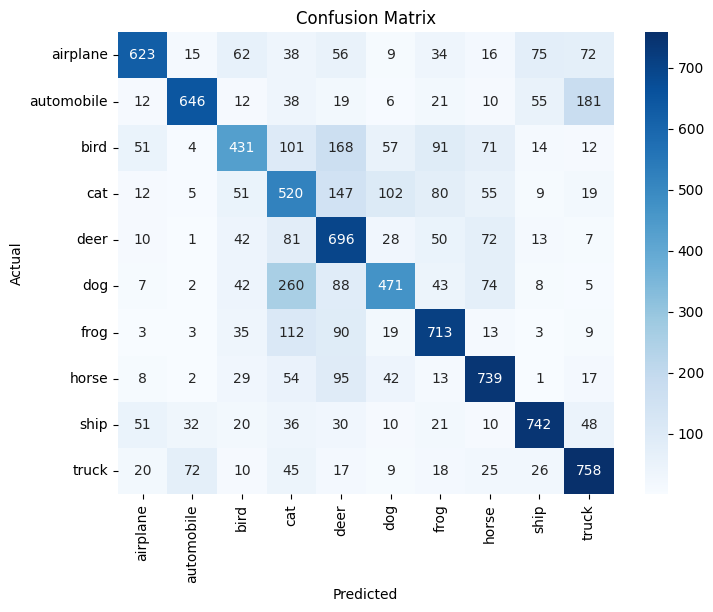

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6339 - loss: 2.2690
Test Accuracy: 0.6339


<Figure size 640x480 with 0 Axes>

In [ ]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
plt.savefig("Confusion.eps",dpi=600)


test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")